In [2]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.61.1-cp312-cp312-macosx_10_13_universal2.whl.metadata (114 kB)
  Using cached kiwisolver-1.4.9-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.3 kB)
Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.61.1-cp312-cp312-macosx_10_13_universal2.whl (2.9 MB)
Using cached kiwisolver-1.4.9-cp312-cp312-macosx_11_0_arm64.whl (64 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 24.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


✓ 그래프가 'z_life_card_analysis.png'로 저장되었습니다.
✓ 적용된 폰트: AppleGothic


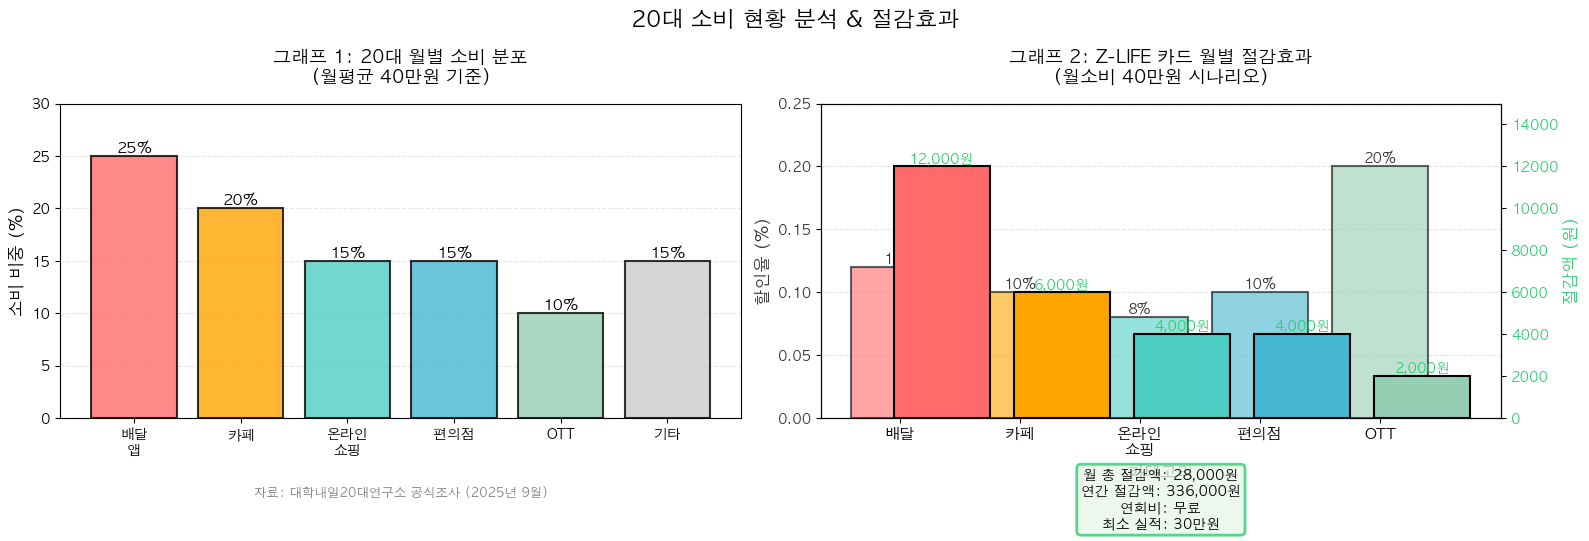

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import font_manager as fm
import numpy as np
import platform

# ==================== 한글 폰트 설정 ====================
# 시스템 OS에 따라 적절한 폰트 자동 선택
system = platform.system()

if system == 'Windows':
    font_name = 'Malgun Gothic'  # Windows: 맑은 고딕
elif system == 'Darwin':  # macOS
    font_name = 'AppleGothic'
else:  # Linux
    font_name = 'DejaVu Sans'

try:
    plt.rcParams['font.family'] = font_name
except:
    print(f"Warning: {font_name} not found. Using default font.")
    
plt.rcParams['axes.unicode_minus'] = False

# ==================== 그래프 생성 ====================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('20대 소비 현황 분석 & 절감효과', fontsize=16, fontweight='bold', y=0.98)

# ==================== GRAPH 1: 20대 월별 소비 현황 ====================
ax1 = axes[0]

categories = ['배달\n앱', '카페', '온라인\n쇼핑', '편의점', 'OTT', '기타']
spending_ratio = [25, 20, 15, 15, 10, 15]  # 비중 (%)
colors_1 = ['#FF6B6B', '#FFA500', '#4ECDC4', '#45B7D1', '#96CEB4', '#CCCCCC']

bars1 = ax1.bar(categories, spending_ratio, color=colors_1, edgecolor='black', linewidth=1.5, alpha=0.8)

# 값 라벨 추가
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_ylabel('소비 비중 (%)', fontsize=12, fontweight='bold')
ax1.set_title('그래프 1: 20대 월별 소비 분포\n(월평균 40만원 기준)', fontsize=13, fontweight='bold', pad=15)
ax1.set_ylim(0, 30)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# 데이터 출처 추가
ax1.text(0.5, -0.25, '자료: 대학내일20대연구소 공식조사 (2025년 9월)', 
         transform=ax1.transAxes, ha='center', fontsize=9, style='italic', color='gray')

# ==================== GRAPH 2: Z-LIFE 카드 이용 시 절감효과 ====================
ax2 = axes[1]

# 절감 시나리오 데이터
categories_2 = ['배달', '카페', '온라인\n쇼핑', '편의점', 'OTT']
spending_amount = [100000, 60000, 50000, 40000, 10000]  # 소비액 (원)
card_discount = [0.12, 0.10, 0.08, 0.10, 0.20]  # 할인율
savings_amount = [12000, 6000, 4000, 4000, 2000]  # 절감액 (원)
colors_2 = ['#FF6B6B', '#FFA500', '#4ECDC4', '#45B7D1', '#96CEB4']

# 2개의 y축 사용
ax2_twin = ax2.twinx()

# 왼쪽: 할인율 (%)
bars2_left = ax2.bar(np.arange(len(categories_2)), card_discount, 
                     color=colors_2, edgecolor='black', linewidth=1.5, alpha=0.6)

# 오른쪽: 절감액 (원)
bars2_right = ax2_twin.bar(np.arange(len(categories_2)) + 0.35, savings_amount, 
                          color=colors_2, edgecolor='black', linewidth=1.5, alpha=1.0)

# 값 라벨 추가
for i, (bar_left, bar_right) in enumerate(zip(bars2_left, bars2_right)):
    # 할인율 라벨 (왼쪽)
    ax2.text(bar_left.get_x() + bar_left.get_width()/2., bar_left.get_height(),
            f'{int(card_discount[i]*100)}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')
    
    # 절감액 라벨 (오른쪽)
    ax2_twin.text(bar_right.get_x() + bar_right.get_width()/2., bar_right.get_height(),
                 f'{int(savings_amount[i]):,}원',
                 ha='center', va='bottom', fontsize=10, fontweight='bold', color='#2ECC71')

ax2.set_ylabel('할인율 (%)', fontsize=12, fontweight='bold', color='#333333')
ax2_twin.set_ylabel('절감액 (원)', fontsize=12, fontweight='bold', color='#2ECC71')
ax2.set_xlabel('카테고리', fontsize=12, fontweight='bold')
ax2.set_xticks(np.arange(len(categories_2)))
ax2.set_xticklabels(categories_2, fontsize=11)
ax2.set_title('그래프 2: Z-LIFE 카드 월별 절감효과\n(월소비 40만원 시나리오)', 
             fontsize=13, fontweight='bold', pad=15)
ax2.set_ylim(0, 0.25)
ax2_twin.set_ylim(0, 15000)

# 합계 표시 (한글)
summary_text = f'''월 총 절감액: 28,000원
연간 절감액: 336,000원
연회비: 무료
최소 실적: 30만원'''

ax2.text(0.5, -0.35, summary_text, 
         transform=ax2.transAxes, ha='center', fontsize=10, 
         bbox=dict(boxstyle='round', facecolor='#E8F5E9', alpha=0.8, edgecolor='#2ECC71', linewidth=2),
         fontweight='bold')

ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)

# 축 색상 설정
ax2.yaxis.label.set_color('#333333')
ax2_twin.yaxis.label.set_color('#2ECC71')
ax2.tick_params(axis='y', labelcolor='#333333')
ax2_twin.tick_params(axis='y', labelcolor='#2ECC71')

plt.tight_layout()
plt.savefig('z_life_card_analysis.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✓ 그래프가 'z_life_card_analysis.png'로 저장되었습니다.")
print(f"✓ 적용된 폰트: {font_name}")
plt.show()
